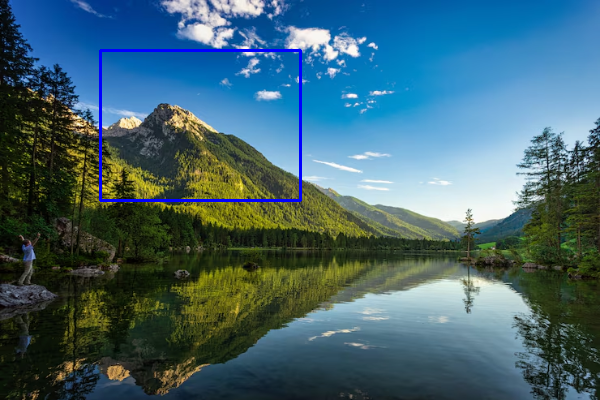

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # For displaying images in Colab

def draw_rectangle_on_image(width, height, rect_x, rect_y, rect_width, rect_height, image_path=None):
    """
    Creates an image (either white or from a file) of specified size
    and draws a blue rectangle on it.

    Args:
        width (int): The target width of the image.
        height (int): The target height of the image.
        rect_x (int): The x-coordinate of the top-left corner of the rectangle.
        rect_y (int): The y-coordinate of the top-left corner of the rectangle.
        rect_width (int): The width of the rectangle.
        rect_height (int): The height of the rectangle.
        image_path (str, optional): Path to an image file. If provided, this image
                                    will be loaded and resized. If None, a white
                                    image will be created. Defaults to None.

    Returns:
        numpy.ndarray: The image with the drawn rectangle, or None if image loading fails.
    """
    if image_path:
        image = cv2.imread(image_path)
        if image is None:
            print(f"Error: Could not load image from {image_path}")
            return None
        # Resize the loaded image to the desired width and height
        image = cv2.resize(image, (width, height))
    else:
        # Create a white image (height, width, channels) - 255 for white, 3 channels for BGR
        image = np.ones((height, width, 3), dtype=np.uint8) * 255

    # Define the top-left and bottom-right corners of the rectangle
    top_left = (rect_x, rect_y)
    bottom_right = (rect_x + rect_width, rect_y + rect_height)

    # Draw a blue rectangle (BGR color: (255, 0, 0) for blue), thickness of 2
    cv2.rectangle(image, top_left, bottom_right, (255, 0, 0), 2)

    return image

# Example usage:
# Define image dimensions
image_width = 600
image_height = 400

# Define rectangle parameters (x, y, width, height)
rectangle_x = 100
rectangle_y = 50
rectangle_width = 200
rectangle_height = 150

# Path to the forest image
forest_image_path = '/content/forest image.avif'

# Create the image with the rectangle, using the forest image as background
output_image = draw_rectangle_on_image(image_width, image_height,
                                           rectangle_x, rectangle_y,
                                           rectangle_width, rectangle_height,
                                           image_path=forest_image_path)

# Display the image in Colab, if it was successfully created
if output_image is not None:
    cv2_imshow(output_image)


### Explanation of the code:

1.  **Import Libraries**: `cv2` for OpenCV functions and `numpy` for array manipulation (to create the image array).
2.  **`create_white_image_with_rectangle` function**:
    *   Takes `width`, `height` for the image size, and `rect_x`, `rect_y`, `rect_width`, `rect_height` for the rectangle's position and size.
    *   `np.ones((height, width, 3), dtype=np.uint8) * 255`: Creates a NumPy array filled with ones, which when multiplied by 255, results in a white image. The `(height, width, 3)` specifies the dimensions (height, width, and 3 for BGR color channels), and `dtype=np.uint8` sets the data type for image pixels.
    *   `cv2.rectangle(image, top_left, bottom_right, (255, 0, 0), 2)`: Draws the rectangle.
        *   `image`: The image on which to draw.
        *   `top_left`: The (x, y) coordinates of the top-left corner of the rectangle.
        *   `bottom_right`: The (x, y) coordinates of the bottom-right corner of the rectangle.
        *   `(255, 0, 0)`: The color of the rectangle in BGR format (Blue, Green, Red). Here, it's blue.
        *   `2`: The thickness of the rectangle's border.
    *   Returns the modified image.
3.  **Example Usage**: Demonstrates how to call the function with sample dimensions and displays the resulting image using `cv2_imshow` which is suitable for Google Colab.